In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import EvaluationTools as et

In [2]:
ai={}
ai['4']=pd.read_csv("/Users/rm026/Documents/code/ReviewPyper_testing/gpt4_vs_5/gpt4_msa_master_list_fixed.csv")
ai['5']=pd.read_csv("/Users/rm026/Documents/code/ReviewPyper_testing/gpt4_vs_5/gpt5_msa_master_list_fixed.csv").drop(['date','Explanation: date'],axis=1)
gt=pd.read_csv('/Users/rm026/Documents/code/ReviewPyper_testing/redacted_msa_ground_truth_no_maybes.csv')
qs=gt.columns[1:]
qs

Index(['gait', 'heel-shin', 'finger-nose', 'dysarthria', 'oculomotor'], dtype='object')

In [3]:
merged={}
for key, val in ai.items():
    merged[key]=pd.merge(val,gt,on='MRN',suffixes=('_ai','_gt'), how='inner')
print(len(ai['4']),len(gt), len(merged))
merged['4']


17 17 2


,MRN,gait_ai,Explanation: gait,heel-shin_ai,Explanation: heel-shin,dysarthria_ai,Explanation: dysarthria,oculomotor_ai,Explanation: oculomotor,finger-nose_ai,Explanation: finger-nose,gait_gt,heel-shin_gt,finger-nose_gt,dysarthria_gt,oculomotor_gt
0,1,1.0,"The text states the patient has impaired gait,...",1.0,The text does not mention the patient's abilit...,1.0,The text does not mention dysarthria or slurre...,1.0,"The text mentions ""saccadic intrusions"" in the...",1.0,"The neurology consult note mentions ""dysdiadok...",1,1,1,1,1
1,2,1.0,The text mentions that the patient has had bal...,1.0,The text does not mention the heel-shin maneuv...,1.0,The text does not mention dysarthria or speech...,1.0,The text does not mention any oculomotor abnor...,1.0,The text does not mention the patient performi...,1,1,1,1,1
2,3,1.0,"The patient requires assistance to walk, has a...",1.0,The exam describes knee-tibia (heel-shin) test...,1.0,"The neurological exam states ""THERE WAS NO dys...",1.0,"The neurological exam notes ""There are full EO...",1.0,"The neurological exam reports ""Finger-nose-fin...",1,1,1,1,1
3,4,1.0,The patient has difficulty walking and a distu...,1.0,The text does not mention difficulty performin...,1.0,The patient’s speech is affected: she is prono...,1.0,The patient has intermittent double vision and...,1.0,The documentation does not mention dysmetria o...,1,1,1,1,1
4,5,1.0,"The patient has difficulty walking, with a wid...",1.0,The patient has difficulty with the knee-tibia...,1.0,The patient’s speech is described as slurred a...,1.0,Oculomotor abnormalities are specifically stat...,1.0,The patient has decomposition and dysmetria of...,1,1,1,1,0
5,6,1.0,"The patient has poor balance, difficulty with ...",1.0,"The first note explicitly states ""Cannot compl...",1.0,"The text says ""There WAS no dysarthria"" and ""N...",1.0,"The neurological exam notes ""horizontal gaze-e...",1.0,"The neurological exams note ""L>R dysmetria on ...",1,0,1,0,1
6,7,1.0,The patient is essentially wheelchair bound an...,1.0,Knee-tibia (heel-shin) test is described with ...,1.0,The patient has moderate-to-severely slurred s...,1.0,Oculomotor abnormalities are repeatedly docume...,1.0,Finger-to-nose is described with segmented/osc...,1,1,0,1,1
7,8,1.0,The patient is described as using a wheelchair...,0.0,The text does not mention the heel-shin maneuv...,0.0,The text does not mention dysarthria or slurre...,1.0,"The most recent note mentions ""some mild cereb...",0.0,The neurological exam states there is no dysme...,1,0,0,0,1
8,9,1.0,"The patient has significant gait ataxia, requi...",1.0,The text does not mention the patient attempti...,1.0,The patient has moderate dysarthria and unclea...,1.0,There are oculomotor abnormalities mentioned: ...,1.0,"There is dysmetria in finger-to-nose testing, ...",1,0,1,1,1
9,10,1.0,The text states the patient is mostly wheelcha...,1.0,The text mentions problems performing the heel...,1.0,The text states there is dysarthria and speech...,1.0,The text describes horizontal nystagmus in ext...,1.0,The text mentions dysmetric finger-to-nose tes...,1,1,1,1,1


In [4]:
test=et.confusion_matrix(merged['4']['gait_gt'],merged['4']['gait_ai'], dimension=2)
test

array([[17,  0],
       [ 0,  0]])

In [5]:
confs={}
for key, val in merged.items():
    confs[key]={}
    for q in qs:
        confs[key][q]=et.confusion_matrix(merged[key][q+'_gt'],merged[key][q+'_ai'], dimension=2)

conf_matrices={key:sum(val.values()) for key, val in confs.items()}
print(conf_matrices)
print(et.accuracy(conf_matrices['4']),et.accuracy(conf_matrices['5']))

{'4': array([[73,  0],
       [ 6,  6]]), '5': array([[73,  0],
       [ 4,  8]])}
0.9294117647058824 0.9529411764705882


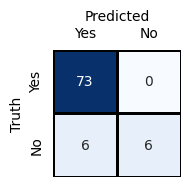

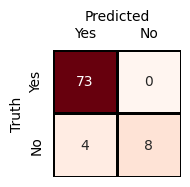

In [13]:
et.plot_conf_matrix(conf_matrices['4'],
                 figsz=(2,2), 
                 filename=f'/Users/rm026/Documents/code/ReviewPyper_testing/gpt4_vs_5/gpt4_confidence_matrix.svg')
et.plot_conf_matrix(conf_matrices['5'],
                 figsz=(2,2), 
                 filename=f'/Users/rm026/Documents/code/ReviewPyper_testing/gpt4_vs_5/gpt5_confidence_matrix.svg',
                 cmap='Reds')

In [7]:
results={}
results={key:et.statistical_df(val).round(3) for key, val in confs.items()}
results['4']


/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:43: RuntimeWarning: invalid value encountered in scalar divide
  return true_negatives/ground_truth_neg
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:53: RuntimeWarning: invalid value encountered in scalar divide
  return true_negatives/predicted_negatives
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:43: RuntimeWarning: invalid value encountered in scalar divide
  return true_negatives/ground_truth_neg
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:53: RuntimeWarning: invalid value encountered in scalar divide
  return true_negatives/predicted_negatives


,question,accuracy,specificity,sensitivity,positive predictive power,negative predictive power
0,gait,1.000,NaN,1.0,1.000,NaN
1,heel-shin,0.824,0.400,1.0,0.800,1.0
2,finger-nose,0.941,0.667,1.0,0.933,1.0
3,dysarthria,0.941,0.667,1.0,0.933,1.0
4,oculomotor,0.941,0.000,1.0,0.941,NaN
5,overall,0.929,0.500,1.0,0.924,1.0


In [8]:
results['5']

,question,accuracy,specificity,sensitivity,positive predictive power,negative predictive power
0,gait,1.000,NaN,1.0,1.000,NaN
1,heel-shin,0.882,0.600,1.0,0.857,1.0
2,finger-nose,0.941,0.667,1.0,0.933,1.0
3,dysarthria,1.000,1.000,1.0,1.000,1.0
4,oculomotor,0.941,0.000,1.0,0.941,NaN
5,overall,0.953,0.667,1.0,0.948,1.0


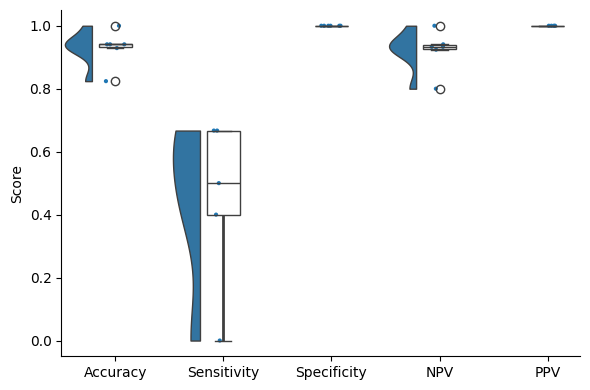

In [15]:
et.raincloud_plot(results['4'], ylims=(-0.05,1.05), filename=f'/Users/rm026/Documents/code/ReviewPyper_testing/gpt4_vs_5/gpt4_evaluation_plot.svg')

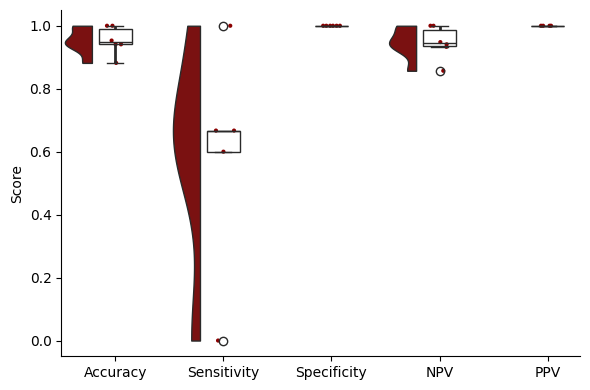

In [16]:
et.raincloud_plot(results['5'], ylims=(-0.05,1.05), color='darkred', filename=f'/Users/rm026/Documents/code/ReviewPyper_testing/gpt4_vs_5/gpt5_evaluation_plot.svg')